In [1]:
import networkx as nx
import pandas as pd

In [2]:
# Load data
cities = pd.read_csv("network_nodes_car.csv")          # columns: name, station, lat, lon
connections = pd.read_csv("network_edges_car.csv")  # columns: from, to

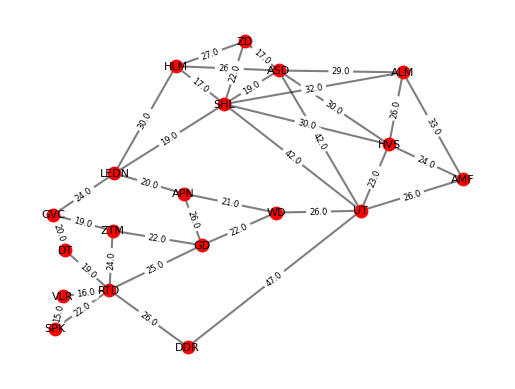

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Make sure lat/lng are numeric
cities["lat"] = pd.to_numeric(cities["lat"], errors="coerce")
cities["lng"] = pd.to_numeric(cities["lng"], errors="coerce")

# Drop rows with missing coordinates
cities = cities.dropna(subset=["lat", "lng"])

# Create the graph
G = nx.Graph()

# Add nodes with coordinates and station info
for _, row in cities.iterrows():
    G.add_node(
        row["name"],
        station=row.get("station", None),
        lat=row["lat"],
        lon=row["lng"]
    )

# Add edges, ensuring no duplicates
seen_edges = set()
for _, row in connections.iterrows():
    a, b = row["from"], row["to"]
    if a in G and b in G and a != b:
        edge = tuple(sorted([a, b]))
        if edge not in seen_edges:
            weight = row.get("time", 1)  # optional: use weight if present
            G.add_edge(a, b, weight=weight)
            seen_edges.add(edge)

# Define positions based on coordinates
pos = {row["name"]: (row["lng"], row["lat"]) for _, row in cities.iterrows()}

# Draw graph nodes and edges
nx.draw_networkx_edges(G, pos, alpha=0.5, width=1.5)
nx.draw_networkx_nodes(G, pos, node_size=80, node_color="red")
nx.draw_networkx_labels(G, pos, font_size=8)

# If edges have weights, add them
if nx.get_edge_attributes(G, "weight"):
    edge_labels = {
        (u, v): f"{data['weight']:.1f}"
        for u, v, data in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.axis("off")
plt.show()

In [4]:
def evaluate_network_metrics(network):
    dcn = nx.degree_centrality(network)
    ccn = nx.closeness_centrality(network, distance='weight')
    bcn = nx.betweenness_centrality(network, weight='weight', normalized=True)
    lcn = nx.clustering(network, weight='weight')
    eigenvector = nx.eigenvector_centrality(network, weight='weight')

    metrics_df = pd.DataFrame({
        'Node': list(network.nodes()),
        'Station': [network.nodes[n]['station'] for n in network.nodes()],
        'DCN':  [round(dcn[n],  4) for n in network.nodes()],
        'CCN':  [round(ccn[n],  4) for n in network.nodes()],
        'BCN':  [round(bcn[n],  4) for n in network.nodes()],
        'LCN':  [round(lcn[n],  4) for n in network.nodes()],
        'EC':   [round(eigenvector[n], 4) for n in network.nodes()],
    })

    metrics_df = metrics_df.sort_values('DCN', ascending=False).reset_index(drop=True)
    return metrics_df

In [5]:
evaluate_network_metrics(G)

,Node,Station,DCN,CCN,BCN,LCN,EC
0,SHL,Schiphol Airport,0.3889,0.0191,0.2778,0.2294,0.4336
1,UT,Utrecht Centraal,0.3333,0.0174,0.1438,0.1673,0.4575
2,ASD,Amsterdam Centraal,0.3333,0.0161,0.0327,0.2914,0.4189
3,RTD,Rotterdam Centraal,0.3333,0.0165,0.2712,0.0582,0.0466
4,HVS,Hilversum,0.2778,0.0161,0.0686,0.4179,0.3756
5,HLM,Haarlem,0.2222,0.0157,0.0000,0.3054,0.1956
6,LEDN,Leiden Centraal,0.2222,0.0201,0.3366,0.0756,0.1159
7,ALM,Almere Centrum,0.2222,0.0139,0.0000,0.3934,0.3259
8,GD,Gouda,0.2222,0.0186,0.1209,0.1650,0.0361
9,APN,Alphen a/d Rijn,0.1667,0.0188,0.0621,0.1624,0.0402
